# Import libraries

In [1]:
# Bibliotecas para importação e análise inicial dos dados
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Bibliotecas para Classificação
from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedStratifiedKFold, cross_validate
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.metrics import roc_curve, auc, roc_auc_score

# definição do estilo estético das plotagens
sns.set_style()

# filtragem de warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# melhorar a apresentação dos valores numéricos
pd.options.display.float_format = '{:20,.2f}'.format

# Opções de Display
pd.set_option('display.max_rows', None)
pd.set_option('display.max_info_rows', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Aparecer todas as colunas durante a exibição
pd.set_option('display.max_columns', None)

### **Explicação**
1. **Importação de Bibliotecas**:
   - `pandas` para manipulação de dados tabulares.
   - `seaborn` e `matplotlib.pyplot` para visualização de dados.
   - `numpy` para operações matemáticas e manipulação de arrays.
   - `sklearn.model_selection`: métodos para dividir os dados e validar modelos.
   - `sklearn.metrics`: métricas de avaliação de modelos.

2. **Configuração do Estilo de Gráficos**:
   - `sns.set_style()` define um estilo estético para os gráficos.

3. **Supressão de Warnings**:
   - `warnings.filterwarnings('ignore')` evita a exibição de mensagens de aviso.

4. **Configuração de Exibição do Pandas**:
   - `pd.options.display.float_format = '{:20,.2f}'.format` melhora a exibição de números decimais.
   - Configurações de `pd.set_option` para exibir todas as linhas e colunas do DataFrame.

# Carregamento dos dados (credit_data.csv) - Disponível no Moodle

clientid: inclui id do cliente  
income: inclui distribuição de renda  
age: Idade dos inadimplentes  
loan: Valor do empréstimo existente  
default: Registros históricos dos inadimplentes  

In [3]:
df = pd.read_csv('credit_data.csv')

In [4]:
df.head(5)

,clientid,income,age,loan,default
0,1,"66,155.93",59.02,"8,106.53",0
1,2,"34,415.15",48.12,"6,564.75",0
2,3,"57,317.17",63.11,"8,020.95",0
3,4,"42,709.53",45.75,"6,103.64",0
4,5,"66,952.69",18.58,"8,770.10",1


In [5]:
print('Número de linhas do dataset: ', df.shape[0])
print('Número de colunas do dataset: ', df.shape[1])

Número de linhas do dataset:  2000
Número de colunas do dataset:  5


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column    Dtype  
---  ------    -----  
 0   clientid  int64  
 1   income    float64
 2   age       float64
 3   loan      float64
 4   default   int64  
dtypes: float64(3), int64(2)
memory usage: 78.3 KB


### **Explicação**
1. `pd.read_csv('credit_data.csv')` carrega os dados do arquivo CSV.
2. `df.head()` exibe as 5 primeiras linhas.
3. `df.shape` retorna `(n_linhas, n_colunas)`.
4. `df.info()` fornece informações sobre os tipos de dados e valores nulos.

In [7]:
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
clientid,"2,000.00","1,000.50",577.49,1.00,500.75,"1,000.50","1,500.25","2,000.00"
income,"2,000.00","45,331.60","14,326.33","20,014.49","32,796.46","45,789.12","57,791.28","69,995.69"
age,"1,997.00",40.81,13.62,-52.42,28.99,41.32,52.59,63.97
loan,"2,000.00","4,444.37","3,045.41",1.38,"1,939.71","3,974.72","6,432.41","13,766.05"
default,"2,000.00",0.14,0.35,0.00,0.00,0.00,0.00,1.00


### **Explicação**
- Retorna estatísticas descritivas das colunas numéricas: média, desvio padrão, mínimos e máximos.

Idade negativa?!
Vamos identificar e remover tais registros.

Aqui vamos remover, mas podemos utilizar de técnicas de data augmentation ou data inputation para 'atualiza-los'.

In [8]:
print(f"Linhas removidas por idade <= 0: {(df['age'] <= 0).sum()}")
print(f"Linhas removidas por valores nulos: {df.isnull().sum().sum()}")
df = df[df['age']>0].dropna()

Linhas removidas por idade <= 0: 3
Linhas removidas por valores nulos: 3


### **Explicação**
- `df[df['age']>0]`: Remove registros com `age <= 0`.
- `.dropna()` Remove valores nulos.

Ainda na coluna idade, vamos deixar como valor inteiro, uma vez que faz mais sentido.

In [9]:
df['age'] = df['age'].astype(int)

### **Explicação**
- Converte a idade para `int`.

In [10]:
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
clientid,"1,994.00","1,003.43",575.88,1.00,505.25,"1,003.50","1,501.75","2,000.00"
income,"1,994.00","45,328.86","14,326.78","20,014.49","32,812.34","45,785.95","57,782.05","69,995.69"
age,"1,994.00",40.43,13.28,18.00,29.00,41.00,52.00,63.00
loan,"1,994.00","4,443.24","3,046.88",1.38,"1,934.22","3,971.65","6,438.04","13,766.05"
default,"1,994.00",0.14,0.35,0.00,0.00,0.00,0.00,1.00


Perfeito! Agora vamos verificar se há valores faltantes.

In [11]:
print("\n=== Análise de valores faltantes ===")
missing_values = df.isnull().sum()
missing_percentages = (missing_values / len(df)) * 100
print("\nContagem e porcentagem de valores faltantes:")
for col, count in missing_values.items():
    print(f"{col}: {count} ({missing_percentages[col]:.2f}%)")

# print(((df.isnull().sum() / df.shape[0]) * 100).sort_values(ascending=False)) # mais 'direto' e já em ordem


=== Análise de valores faltantes ===

Contagem e porcentagem de valores faltantes:
clientid: 0 (0.00%)
income: 0 (0.00%)
age: 0 (0.00%)
loan: 0 (0.00%)
default: 0 (0.00%)


Não há valores faltantes.

### **Explicação**
- Calcula e exibe a quantidade e a porcentagem de valores nulos.

A coluna `clientid` não fornece nenhuma informação relevante para a modelagem, iremos remove-la.

In [12]:
df.drop(['clientid'], axis=1, inplace=True)

### **Explicação**
- Remove a coluna `clientid`, que provavelmente é um identificador único e irrelevante para a análise.

# Análise Exploratória dos Dados

## Informações básicas sobre o conjunto de dados

In [13]:
print("\n=== Dataset Overview ===")
print("\nDataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)


=== Dataset Overview ===

Dataset Shape: (1994, 4)

Data Types:
income     float64
age          int64
loan       float64
default      int64
dtype: object


# Estatísticas descritivas

In [14]:
print("\n=== Estatísticas descritivas ===")
print("\nVariáveis Numéricas:")
print(df[['income', 'age', 'loan']].describe())


=== Estatísticas descritivas ===

Variáveis Numéricas:
                    income                  age                 loan
count             1,994.00             1,994.00             1,994.00
mean             45,328.86                40.43             4,443.24
std              14,326.78                13.28             3,046.88
min              20,014.49                18.00                 1.38
25%              32,812.34                29.00             1,934.22
50%              45,785.95                41.00             3,971.65
75%              57,782.05                52.00             6,438.04
max              69,995.69                63.00            13,766.05


# Análise da taxa de inadimplência

In [15]:
default_rate = (df['default'].value_counts(normalize=True) * 100).round(2)
print("\nTaxa de Inadimplência (normalizada):")
print(default_rate)


Taxa de Inadimplência (normalizada):
default
0                  85.81
1                  14.19
Name: proportion, dtype: float64


# Análise de correlação

In [16]:
correlation_matrix = df[['income', 'age', 'loan', 'default']].corr()
print("\n=== Matriz de Correlação ===")
print(correlation_matrix)


=== Matriz de Correlação ===
                      income                  age                 loan              default
income                  1.00                -0.03                 0.44                 0.00
age                    -0.03                 1.00                 0.01                -0.45
loan                    0.44                 0.01                 1.00                 0.38
default                 0.00                -0.45                 0.38                 1.00


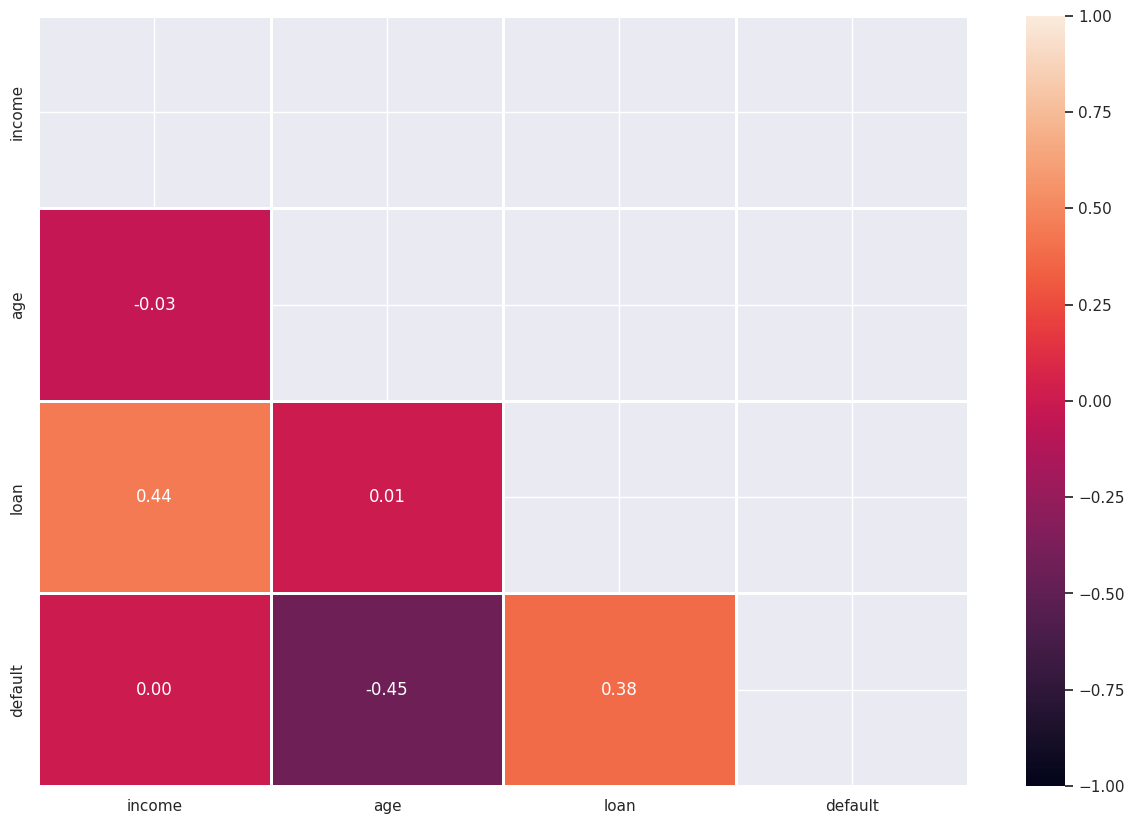

In [17]:
# plt.figure(figsize=(10, 6))
# correlation_matrix = df[['income', 'age', 'loan', 'default']].corr()
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
# plt.title('Matriz de Correlação')
# plt.tight_layout()
# plt.show()

sns.set(font_scale=1)
matrix = np.triu(df.corr())
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), annot = True,
            cmap = 'rocket', fmt=".2f",
            mask = matrix, vmin = -1, vmax = 1,
            linewidths = 1, linecolor = 'white')
plt.show()

# Gráficos

<Axes: >

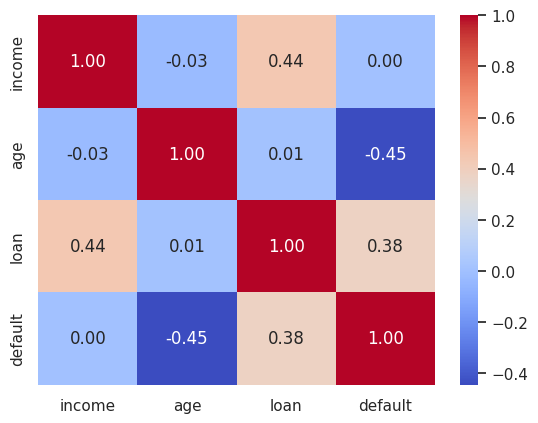

In [18]:
correlation_matrix = df[['income', 'age', 'loan', 'default']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

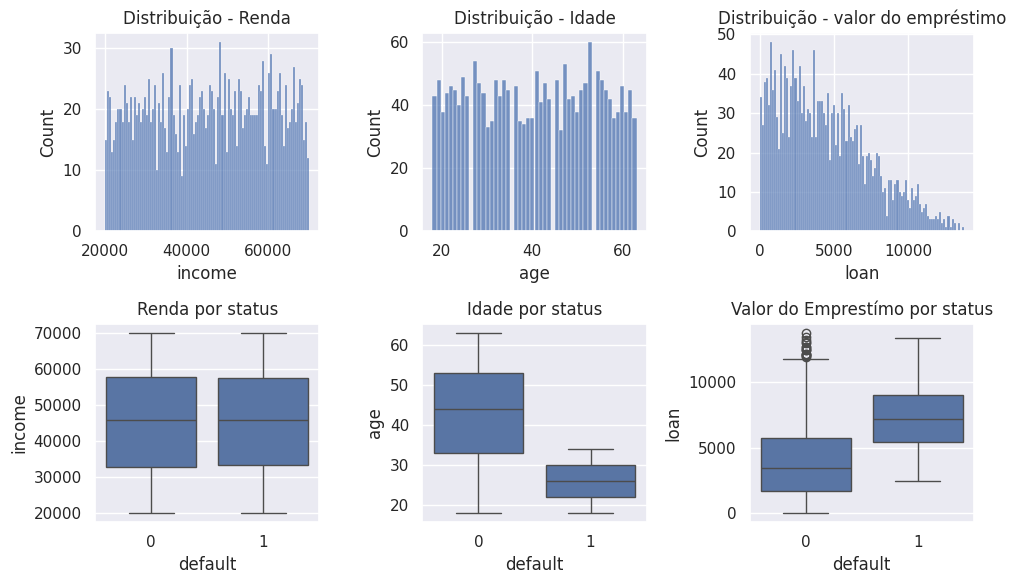

In [19]:
fig = plt.figure(figsize=(10, 6))

# Distribution plots for numerical variables
plt.subplot(231)
sns.histplot(data=df, x='income', bins=100)
plt.title('Distribuição - Renda')

plt.subplot(232)
sns.histplot(data=df, x='age', bins=50)
plt.title('Distribuição - Idade')

plt.subplot(233)
sns.histplot(data=df, x='loan', bins=100)
plt.title('Distribuição - valor do empréstimo')

# Box plots for numerical variables by default status
plt.subplot(234)
sns.boxplot(data=df, x='default', y='income')
plt.title('Renda por status')

plt.subplot(235)
sns.boxplot(data=df, x='default', y='age')
plt.title('Idade por status')

plt.subplot(236)
sns.boxplot(data=df, x='default', y='loan')
plt.title('Valor do Emprestímo por status')

plt.tight_layout()
plt.show()

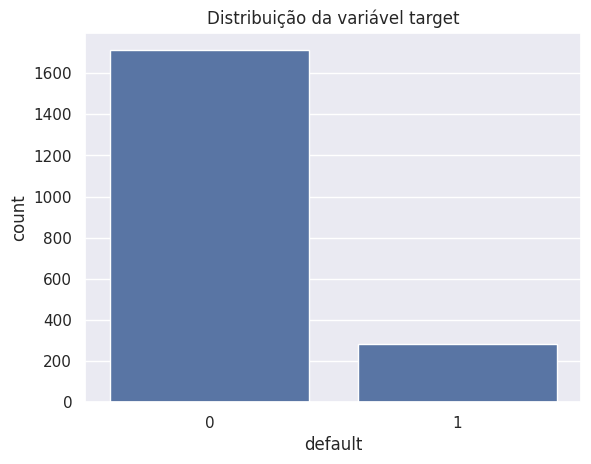

In [20]:
sns.countplot(data=df, x='default')
plt.title('Distribuição da variável target')
plt.show()

Temos alguns outliers em relação ao valor do empréstimo.

In [21]:
# Análise de faixa etária
df['age_group'] = pd.cut(df['age'],
                          bins=[0, 25, 35, 45, 55, 100],
                          labels=['18-25', '26-35', '36-45', '46-55', '55+'])
age_default_rate = df.groupby('age_group')['default'].mean() * 100
print("\nTaxa de inadimplência por faixa etária:")
print(age_default_rate)

# Análise de quartil de renda
df['income_quartile'] = pd.qcut(df['income'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
income_default_rate = df.groupby('income_quartile')['default'].mean() * 100
print("\nTaxa de inadimplência por quartil de renda:")
print(income_default_rate)

# Análise do quartil do valor do empréstimo
df['loan_quartile'] = pd.qcut(df['loan'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
loan_default_rate = df.groupby('loan_quartile')['default'].mean() * 100
print("\nTaxa de inadimplência por quartil do valor do empréstimo:")
print(loan_default_rate)


Taxa de inadimplência por faixa etária:
age_group
18-25                  37.39
26-35                  34.32
36-45                   0.00
46-55                   0.00
55+                     0.00
Name: default, dtype: float64

Taxa de inadimplência por quartil de renda:
income_quartile
Q1                  13.43
Q2                  14.66
Q3                  15.06
Q4                  13.63
Name: default, dtype: float64

Taxa de inadimplência por quartil do valor do empréstimo:
loan_quartile
Q1                   0.00
Q2                   6.22
Q3                  17.07
Q4                  33.47
Name: default, dtype: float64


In [23]:
def top_plot(data, col:str, n:int, title:str):
    top = data[col].value_counts().head(n).sort_values(ascending=False)
    order = top.index
    plt.figure(figsize=(20,5))
    plt.title(title, size=18)
    ax = sns.barplot(y=top.index, x=top, orient='h', order=order)
    ax.set(xlabel=None, ylabel=None)
    for i in ax.containers:
        ax.bar_label(i,)
    plt.show()

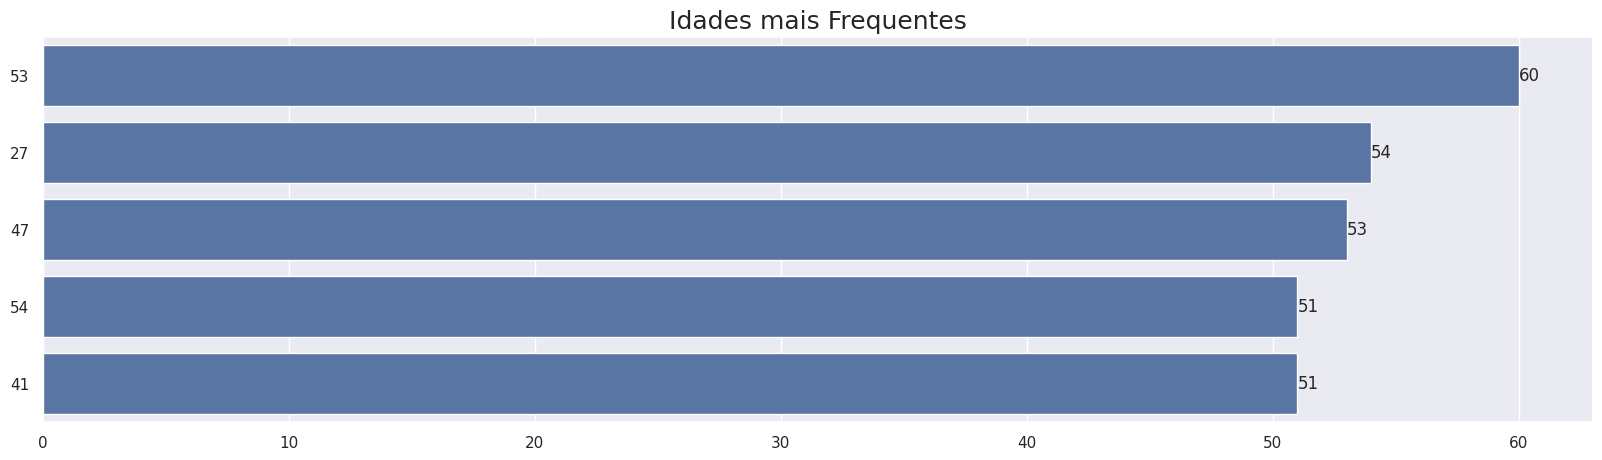

In [24]:
top_plot(df, 'age', 5, 'Idades mais Frequentes')

### **Explicação**
- Cria uma função para exibir os `n` valores mais frequentes de uma coluna.

# Análise bivariada

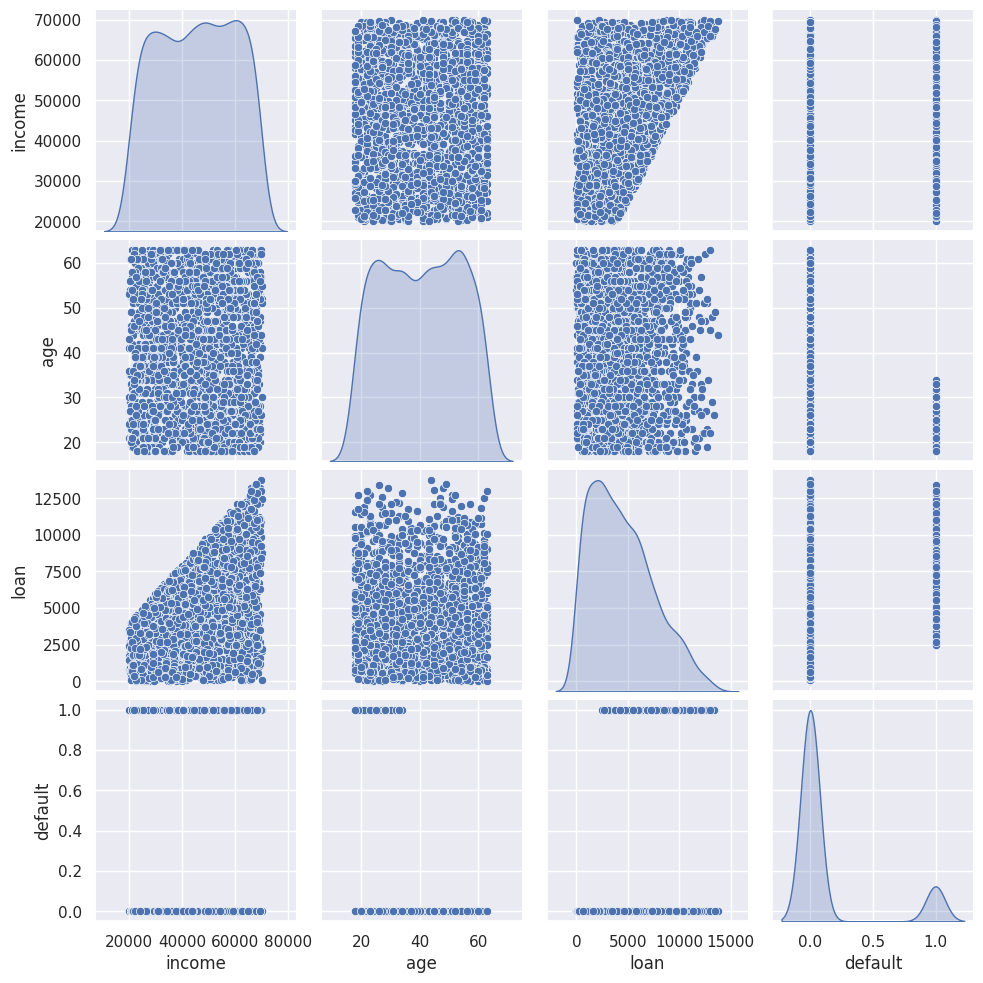

In [25]:
sns.pairplot(df, diag_kind='kde')

#### **Explicação**
O `sns.pairplot()` do **Seaborn** cria uma matriz de gráficos de dispersão para explorar as relações entre múltiplas variáveis numéricas do `df`.  
- `diag_kind='kde'` define que os gráficos da diagonal sejam **Kernel Density Estimation (KDE)**, ou seja, distribuições de densidade em vez de histogramas.

#### **Interpretação**
- Cada gráfico fora da diagonal mostra a relação entre duas variáveis numéricas.
- Os gráficos na diagonal exibem a distribuição univariada das variáveis.
- Ajuda a identificar **correlações**, **distribuições**, **outliers** e possíveis **tendências**.

---
- Dependendo do tamanho do `df`, o `pairplot` pode ser **computacionalmente pesado**. Se houver muitas colunas, uma abordagem mais eficiente seria **selecionar apenas variáveis relevantes**:
---


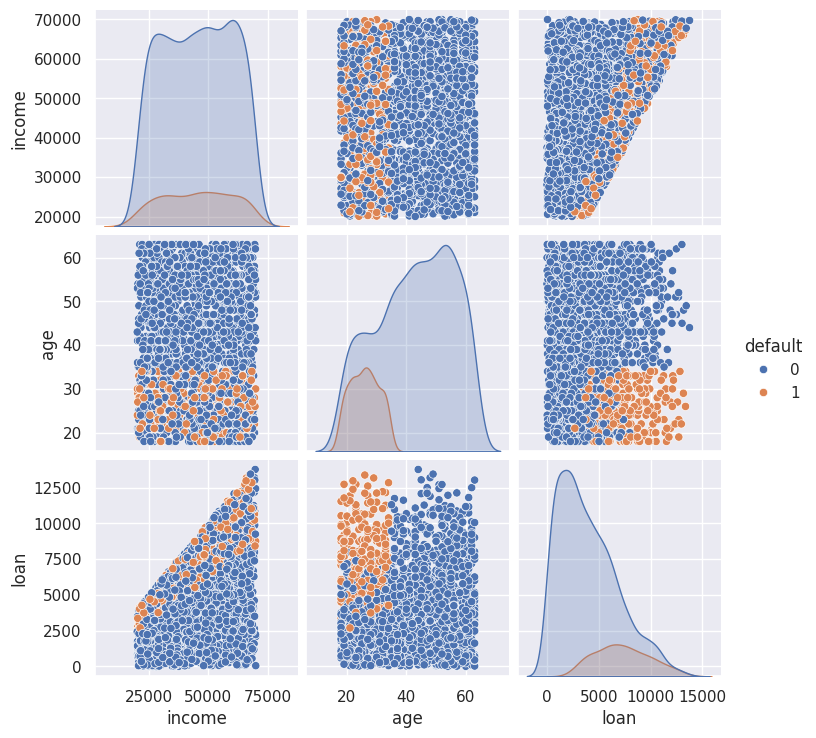

In [26]:
selected_features = ['income', 'age', 'loan', 'default']
sns.pairplot(df[selected_features], diag_kind='kde', hue='default')

 - O parâmetro `hue='default'` adiciona cores baseadas na variável `default`, facilitando a identificação de padrões entre os inadimplentes e não inadimplentes.

# Possíveis Perguntas

1. Quem faz os maiores valores de emprestimo?

Para isso, vamos selecionar os valores acima da mediana, uma vez que já verificamos que é onde ocorre a maior taxa de inadimplência.

In [27]:
# Pergunta: 1. Quem faz os maiores valores de empréstimo?

# Seleciona os empréstimos acima da mediana
median_loan = df['loan'].median()
selected_loans = df.loc[df['loan'] > median_loan].copy()  # Adicionando .copy() para evitar o Warning

# Análise de faixa etária
selected_loans['age_group'] = pd.cut(selected_loans['age'],
                          bins=[0, 25, 35, 45, 55, 100],
                          labels=['18-25', '26-35', '36-45', '46-55', '55+'])

age_default_rate = selected_loans.groupby('age_group')['default'].mean() * 100
print("\nTaxa de inadimplência por faixa etária:")
print(age_default_rate)

# Análise de quartil de renda
selected_loans['income_quartile'] = pd.qcut(selected_loans['income'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
income_default_rate = selected_loans.groupby('income_quartile')['default'].mean() * 100
print("\nTaxa de inadimplência por quartil de renda:")
print(income_default_rate)



Taxa de inadimplência por faixa etária:
age_group
18-25                  68.97
26-35                  63.77
36-45                   0.00
46-55                   0.00
55+                     0.00
Name: default, dtype: float64

Taxa de inadimplência por quartil de renda:
income_quartile
Q1                  32.80
Q2                  25.30
Q3                  20.48
Q4                  22.49
Name: default, dtype: float64


Conseguimos verificar que são pessoas mais jovens que buscam os maiores empréstimos e são consideradas inadimplentes.

Por outro lado, a renda não é tão discriminante em relação a taxa de inadimplência.

#### **Explicação**
Aqui, estamos tentando entender o perfil dos clientes que fazem **empréstimos acima da mediana**.
- **`df['loan'].median()`** calcula a mediana do valor do empréstimo.
- **`df.loc[df['loan'] > median_loan]`** seleciona os clientes cujo empréstimo é **acima da mediana**.
- **`.copy()`** evita o `SettingWithCopyWarning`, criando um novo DataFrame.

1. **Agrupamento por idade**
   - O método `pd.cut()` categoriza a variável `age` em **faixas etárias** predefinidas:
     - `18-25`
     - `26-35`
     - `36-45`
     - `46-55`
     - `55+`
   
2. **Cálculo da Taxa de Inadimplência**
   - `groupby('age_group')['default'].mean() * 100`
     - Agrupa por faixa etária e calcula a **taxa média de inadimplência** (multiplicando por 100 para expressar em porcentagem).

---
3. **Divisão por quartis**  
   - O método `pd.qcut()` divide a variável `income` em **4 quartis** com quantidades iguais de observações:
     - `Q1` (25% mais baixos)
     - `Q2`
     - `Q3`
     - `Q4` (25% mais altos)
   
4. **Cálculo da inadimplência**
   - `groupby('income_quartile')['default'].mean() * 100` calcula a taxa média de inadimplência para cada quartil.     

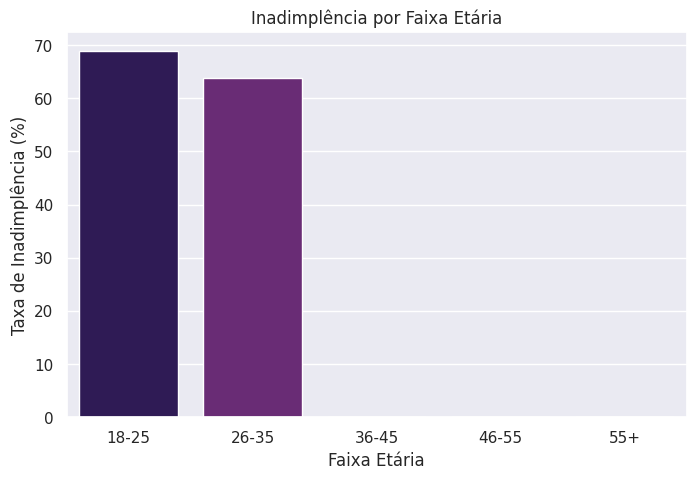

In [28]:
plt.figure(figsize=(8, 5))
sns.barplot(x=age_default_rate.index, y=age_default_rate.values, palette='magma')
plt.xlabel('Faixa Etária')
plt.ylabel('Taxa de Inadimplência (%)')
plt.title('Inadimplência por Faixa Etária')
plt.show()

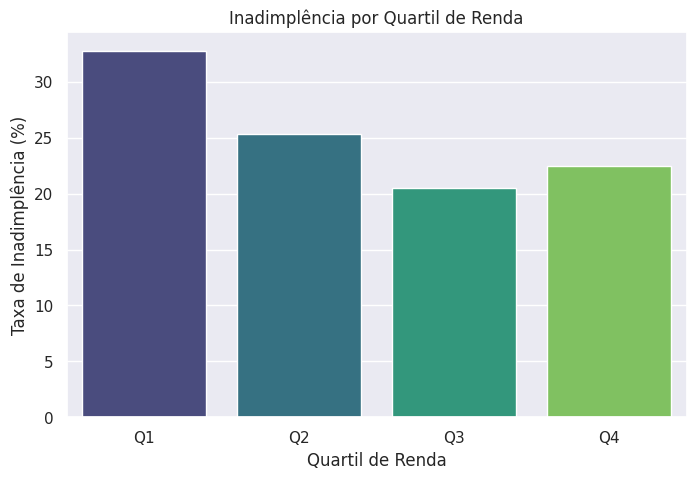

In [29]:
plt.figure(figsize=(8, 5))
sns.barplot(x=income_default_rate.index, y=income_default_rate.values, palette='viridis')
plt.xlabel('Quartil de Renda')
plt.ylabel('Taxa de Inadimplência (%)')
plt.title('Inadimplência por Quartil de Renda')
plt.show()

Podemos fazer outras perguntas em relação aos dados....

# Classificação

In [30]:
df = pd.read_csv('credit_data.csv')
df = df[df['age']>0].dropna()
df['age'] = df['age'].astype(int)
df.drop(['clientid'], axis=1, inplace=True)

# Dividindo os dados em treino e teste

X = df.drop(columns=['default'], axis=1)
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### **Explicação**
1. **Separação de variáveis**  
   - `X = df.drop(columns=['default'], axis=1)`: Remove a coluna **'default'** para usá-la como variável alvo (`y`).  
   - `y = df['default']`: Define **'default'** como a variável alvo.

2. **Divisão treino/teste**  
   - `train_test_split()` divide os dados em **80% para treino e 20% para teste**.  
   - `random_state=42`: Garante reprodutibilidade dos resultados.  
   - `stratify=y`: Mantém a mesma proporção de classes na divisão treino/teste, evitando um **desequilíbrio na distribuição**.

## Árvore de Decisão

referencia: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier

In [31]:
from sklearn import tree

In [32]:
dt = tree.DecisionTreeClassifier(criterion='gini',
                                 splitter='best',
                                 max_depth=None,
                                 min_samples_split=2,
                                 min_samples_leaf=1,
                                 min_weight_fraction_leaf=0.0,
                                 max_features=None,
                                 random_state=None,
                                 max_leaf_nodes=None,
                                 min_impurity_decrease=0.0,
                                 class_weight=None)
dt.fit(X_train,y_train)

DecisionTreeClassifier()

### **Explicação**
1. **Criação do modelo Decision Tree (`dt`)**
   - `criterion='gini'`: Usa o índice de Gini para medir a pureza dos nós.
   - `splitter='best'`: Escolhe o melhor ponto de divisão.
   - `max_depth=None`: Sem limite de profundidade → **pode levar a overfitting**.
   - `min_samples_split=2`: Nó só se divide se houver pelo menos **2 amostras**.
   - `min_samples_leaf=1`: Cada folha precisa ter pelo menos **1 amostra**.
   - `max_features=None`: Considera **todas as features** no processo de decisão.
   - `random_state=None`: Se definido, pode ajudar na **reprodutibilidade**.

2. **Treinamento do modelo**
   - `dt.fit(X_train, y_train)`: O modelo aprende padrões dos dados de treino.

   ---
   ### **Sugestão**
- Para evitar **overfitting**, podemos limitar a profundidade da árvore e ajustar hiperparâmetros:
```python
dt = tree.DecisionTreeClassifier(criterion='gini',
                                 max_depth=5,  # Controla overfitting
                                 min_samples_split=10,
                                 min_samples_leaf=5,
                                 random_state=42)
```
Outra estratégia é usar `GridSearchCV` para **encontrar os melhores parâmetros**.

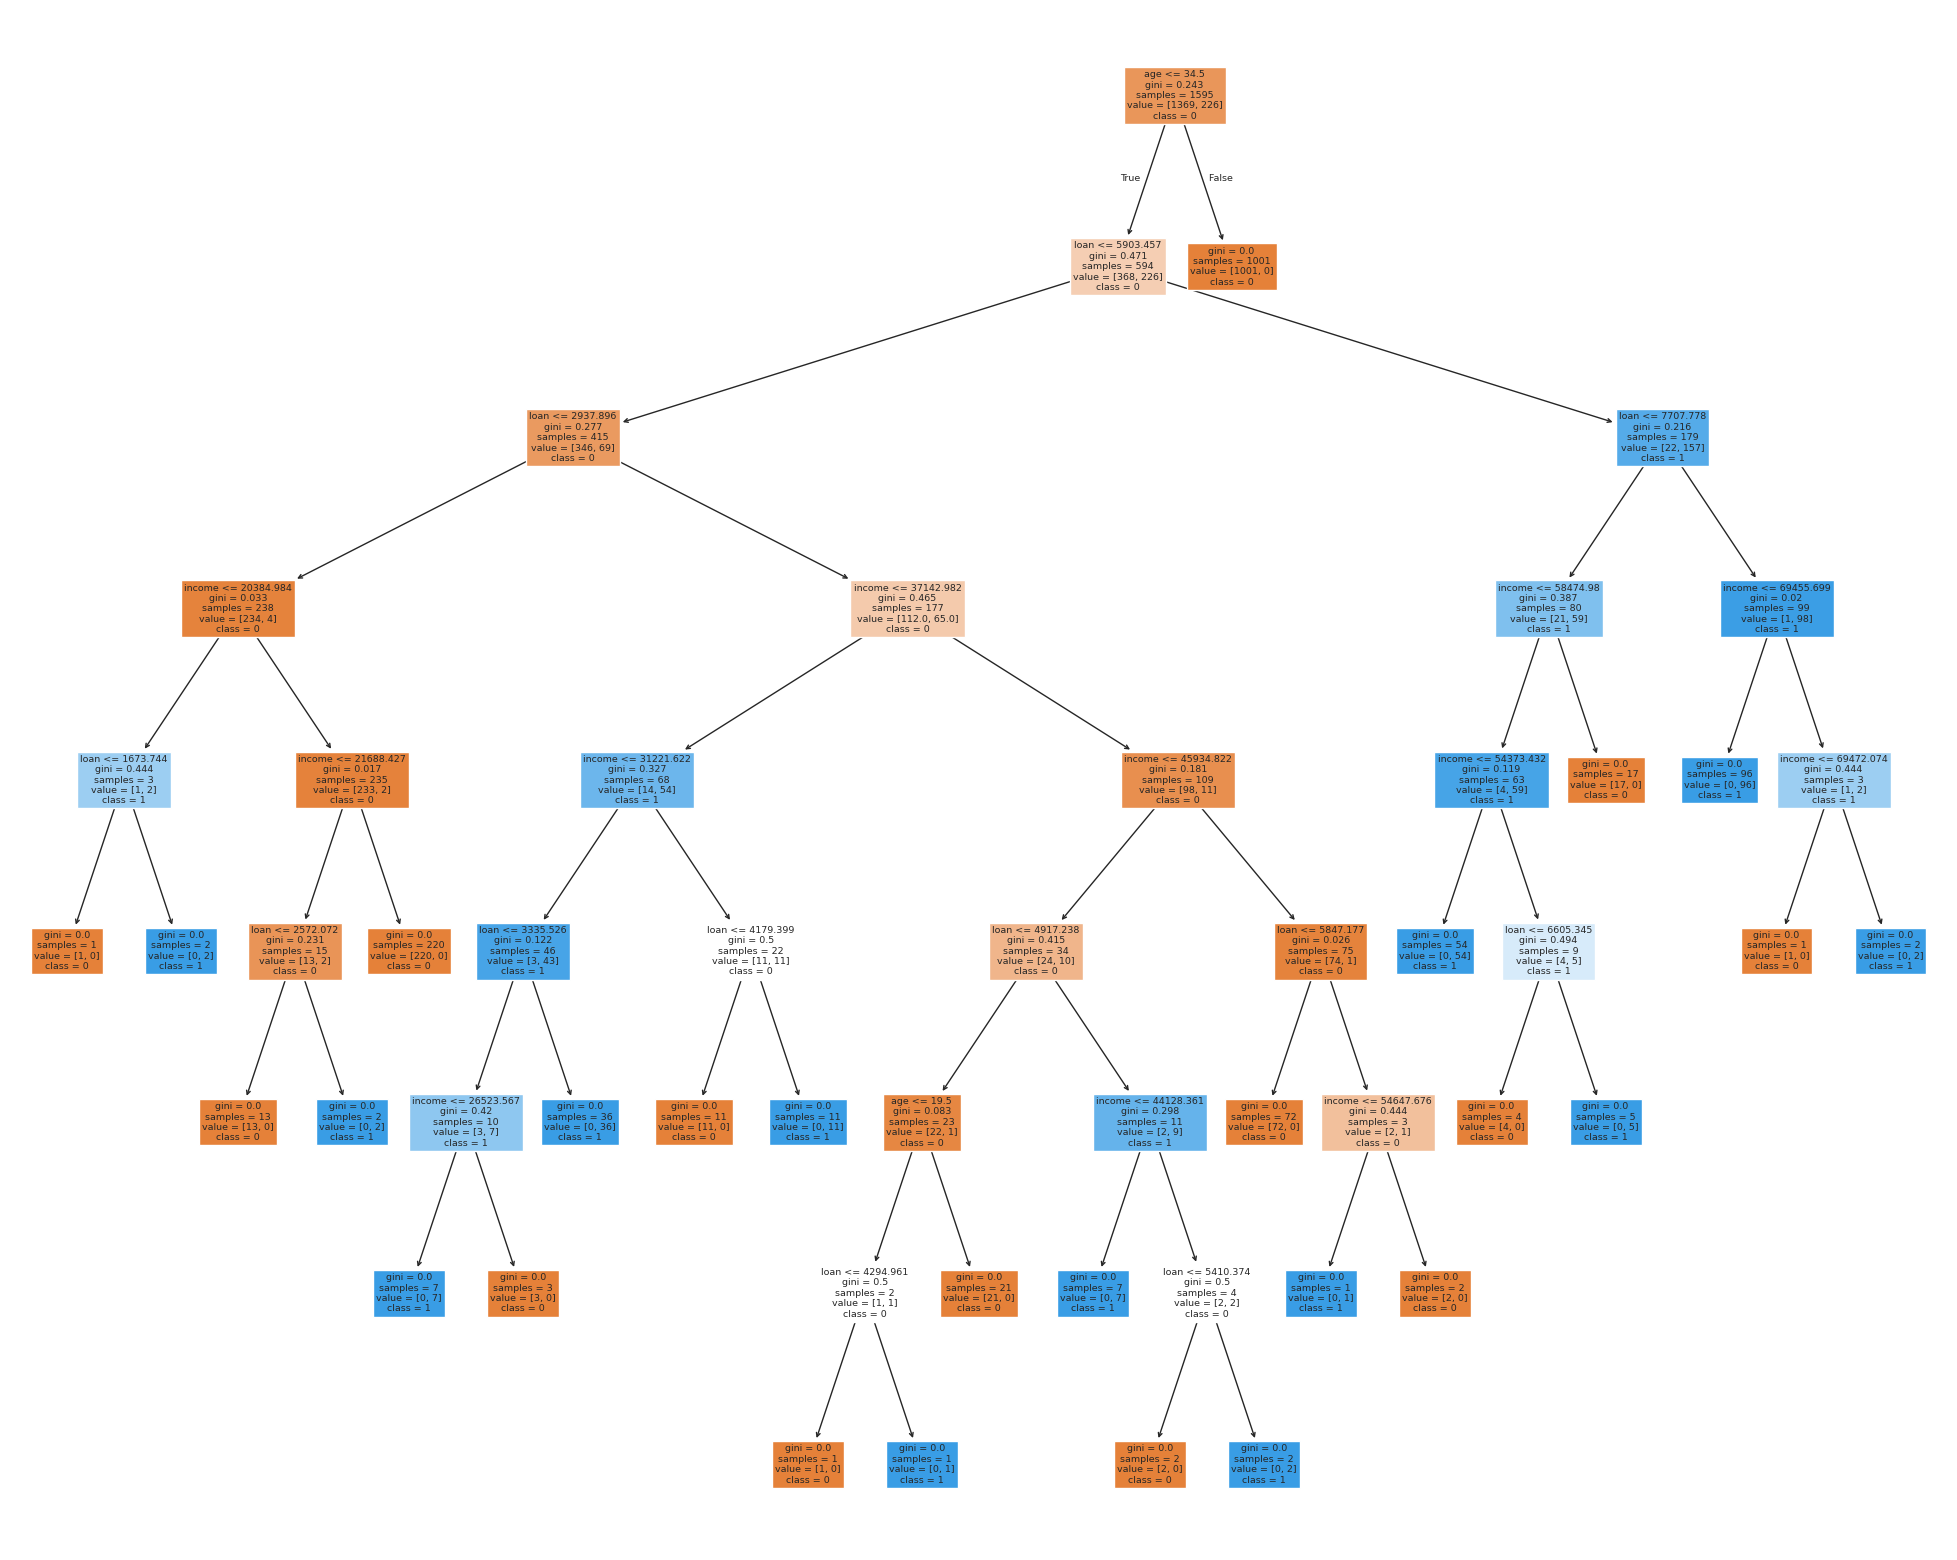

In [33]:
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(dt,
                   feature_names=X.columns.tolist(),
                   class_names=['0','1'],
                   filled=True)

### **Explicação**
- `plt.figure(figsize=(25,20))`: Define o tamanho do gráfico.
- `tree.plot_tree(dt, feature_names=X.columns.tolist(), class_names=['0','1'], filled=True)`:  
  - **Mostra a árvore de decisão** com os nomes das features.
  - `filled=True`: Usa cores para representar classes.

  ---
  ### **Sugestão**
- Para árvores **muito grandes**, a visualização pode ficar **difícil**.  
  - Alternativa: **Exibir apenas os primeiros níveis**:
  ```python
  tree.plot_tree(dt, feature_names=X.columns.tolist(), class_names=['0','1'], filled=True, max_depth=3)
  ```

In [35]:
y_pred_dt = dt.predict(X_test)

### **Explicação**
- O modelo treinado (`dt`) faz previsões no conjunto de teste (`X_test`).

Matriz de Confusão

In [36]:
dt_cm = confusion_matrix(y_true=y_test,
                         y_pred=y_pred_dt)

Text(0.5, 1.0, 'Heatmap for Decision Tree Classification Model')

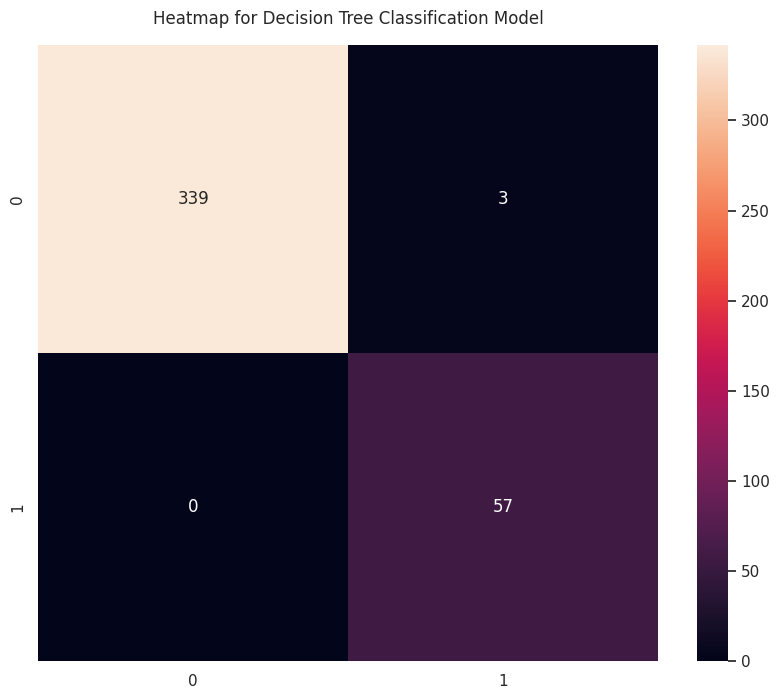

In [37]:
plt.figure(figsize = (10,8))
ax = plt.axes()
x_axis_labels = ['0','1'] # labels for x-axis
y_axis_labels = ['0','1'] # labels for y-axis
vmax = max(np.unique(y_test, return_counts=True)[1])
sns.heatmap(dt_cm,
            vmin=0,
            vmax=vmax,
            annot=True,
            fmt="d",
            ax = ax,
            xticklabels=x_axis_labels,
            yticklabels=y_axis_labels)
# sns.heatmap(dt_cm / np.sum(dt_cm), annot=True, fmt=".2%", cmap="Blues") # versao normalizada
ax.set_title('Heatmap for Decision Tree Classification Model',pad=15)

### **Explicação**
1. **Matriz de Confusão**
   - `confusion_matrix(y_test, y_pred_dt)`: Mostra verdadeiros positivos/negativos e falsos positivos/negativos.
   - `sns.heatmap()`: Plota a matriz como um **heatmap** para facilitar a análise.

In [38]:
print(classification_report(y_test, y_pred_dt, target_names=['0','1']))
print("Accuracy:",accuracy_score(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       342
           1       0.95      1.00      0.97        57

    accuracy                           0.99       399
   macro avg       0.97      1.00      0.98       399
weighted avg       0.99      0.99      0.99       399

Accuracy: 0.9924812030075187


### **Explicação**
1. **`classification_report()`**  
   - Exibe métricas como **precisão, recall e F1-score** para cada classe.

2. **`accuracy_score()`**  
   - Retorna a **acurácia** do modelo.

---
### **SUGESTÃO**
- Se houver **desbalanceamento de classes**, considerar **métricas como MCC (casos binários), F1-Score ou AUC-ROC**, pois a acurácia sozinha pode ser enganosa.

Curva ROC

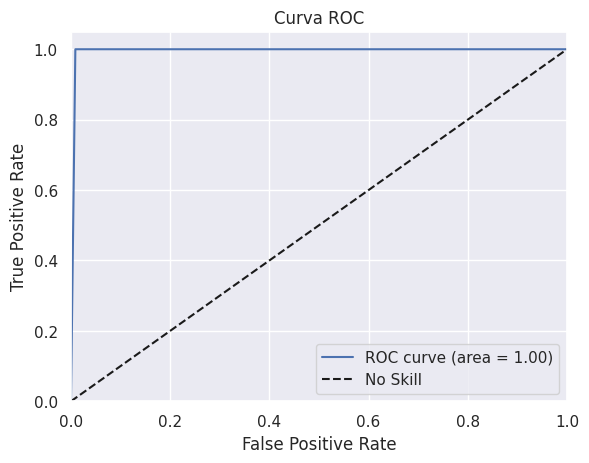

In [39]:
y_pred_proba_dt = dt.predict_proba(X_test)[:,1]

# Calculate ROC curve
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)
# Plot the ROC curve
plt.figure()
plt.plot(fpr_dt, tpr_dt, label='ROC curve (area = %0.2f)' % roc_auc_dt)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()

### **Explicação**
- **ROC curve** mede a **capacidade do modelo de distinguir classes**.
- `roc_auc_dt = auc(fpr_dt, tpr_dt)`: Calcula a **área sob a curva ROC (AUC)**.

Validação Cruzada

In [40]:
n_splits = 10
seed = 7
cv = RepeatedStratifiedKFold(n_splits=n_splits,
                             n_repeats=n_splits,
                             random_state=seed)

In [41]:
n_scores = cross_validate(dt,
                          X,
                          y,
                          scoring='accuracy', #scoring='precision',
                          cv=cv,
                          n_jobs=-1,
                          error_score='raise')
print("Mean:", np.mean(n_scores['test_score']))

Mean: 0.9848072864321609


### **Explicação**
- **Cross-validation** melhora a **generalização do modelo**.
- `RepeatedStratifiedKFold` mantém a **distribuição das classes** em cada iteração.

### **SUGESTÃO**
- Considerar **métricas adicionais** para modelos desbalanceados:
```python
n_scores = cross_validate(dt, X, y, scoring=['accuracy', 'precision', 'recall', 'f1'], cv=cv)
```

## Random Forest

referência: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#sklearn.ensemble.RandomForestClassifier

In [42]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,
                            criterion='gini',
                            max_depth=None,
                            min_samples_split=2,
                            min_samples_leaf=1,
                            min_weight_fraction_leaf=0.0,
                            max_features='sqrt',
                            max_leaf_nodes=None,
                            min_impurity_decrease=0.0,
                            bootstrap=True,
                            oob_score=False,
                            n_jobs=None,
                            random_state=None,
                            verbose=0,
                            warm_start=False,
                            class_weight=None,
                            ccp_alpha=0.0,
                            max_samples=None,
                            monotonic_cst=None)
rf.fit(X_train,y_train)

RandomForestClassifier()

### **Explicação**
Este bloco de código cria e treina um modelo de **Random Forest**, que é um conjunto de múltiplas árvores de decisão. O modelo aprende padrões nos dados para fazer previsões.

- **`n_estimators=100`**: Usa **100 árvores** na floresta.
- **`criterion='gini'`**: Usa **índice de Gini** para medir a pureza dos nós.
- **`max_depth=None`**: Permite que as árvores cresçam **até que todas as folhas sejam puras** ou até o mínimo de amostras permitido.
- **`min_samples_split=2`**: Um nó só será dividido se tiver **pelo menos 2 amostras**.
- **`min_samples_leaf=1`**: Cada folha precisa ter pelo menos **1 amostra**.
- **`max_features='sqrt'`**: Em cada divisão, o modelo considera um número **aleatório de variáveis igual à raiz quadrada do total**. Isso melhora a generalização do modelo.
- **`bootstrap=True`**: Usa **bootstrap sampling**, ou seja, as árvores são treinadas em subconjuntos aleatórios dos dados, o que reduz o overfitting.


In [43]:
y_pred_rf = rf.predict(X_test)

### **Explicação**
- O modelo treinado (`rf`) faz previsões no conjunto de teste (`X_test`).
- As previsões são armazenadas na variável `y_pred_rf`.

Matriz de Confusão

Text(0.5, 1.0, 'Heatmap for Random Forest Classification Model')

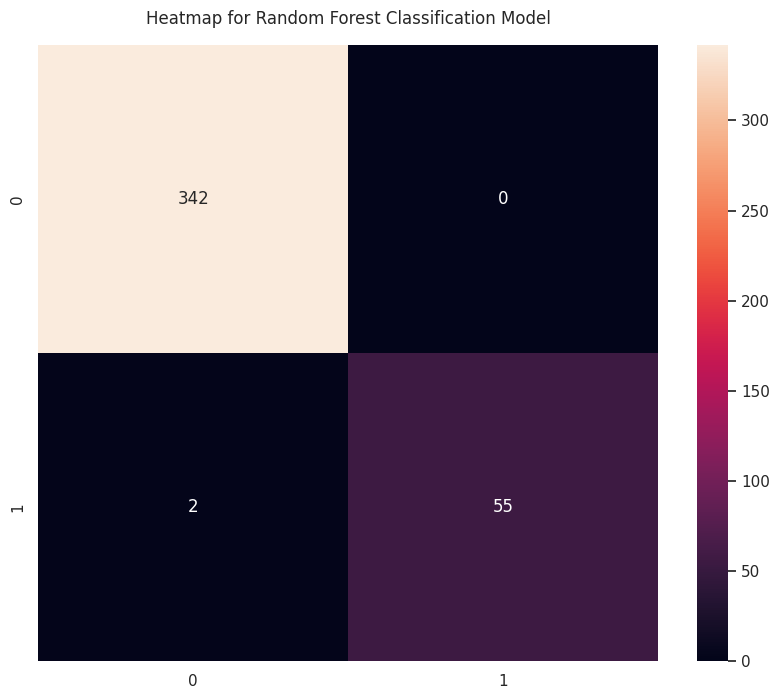

In [44]:
rf_cm = confusion_matrix(y_true=y_test,
                         y_pred=y_pred_rf)

plt.figure(figsize = (10,8))
ax = plt.axes()
x_axis_labels = ['0','1'] # labels for x-axis
y_axis_labels = ['0','1'] # labels for y-axis
vmax = max(np.unique(y_test, return_counts=True)[1])
sns.heatmap(rf_cm,
            vmin=0,
            vmax=vmax,
            annot=True,
            fmt="d",
            ax = ax,
            xticklabels=x_axis_labels,
            yticklabels=y_axis_labels)
ax.set_title('Heatmap for Random Forest Classification Model',pad=15)

### **Explicação**
- A **Matriz de Confusão** ajuda a visualizar o desempenho do modelo:
  - **Verdadeiros Positivos (TP)** e **Verdadeiros Negativos (TN)**: previsões corretas.
  - **Falsos Positivos (FP)** e **Falsos Negativos (FN)**: erros do modelo.
- `sns.heatmap()` visualiza os valores com um mapa de calor.

---

### **SUGESTÃO**
Podemos normalizar a matriz para facilitar a interpretação:
```python
sns.heatmap(rf_cm / np.sum(rf_cm), annot=True, fmt=".2%", cmap="Blues")
```
Isso exibe os valores como **percentuais** em vez de contagens brutas.

In [45]:
print(classification_report(y_test, y_pred_rf, target_names=['0','1']))
print("Accuracy:",accuracy_score(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       342
           1       1.00      0.96      0.98        57

    accuracy                           0.99       399
   macro avg       1.00      0.98      0.99       399
weighted avg       1.00      0.99      0.99       399

Accuracy: 0.9949874686716792


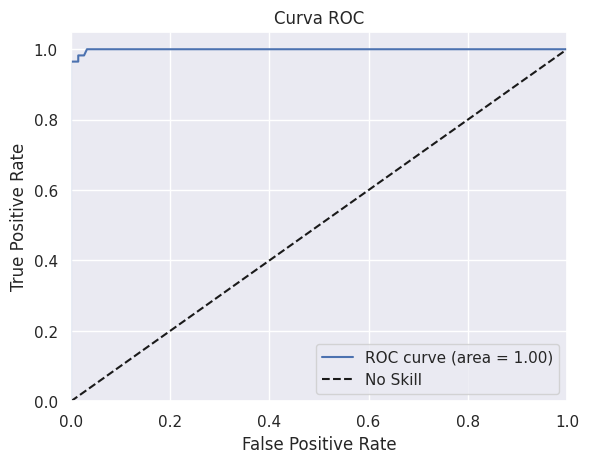

In [46]:
y_pred_proba_rf = rf.predict_proba(X_test)[:,1]

# Calculate ROC curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
# Plot the ROC curve
plt.figure()
plt.plot(fpr_rf, tpr_rf, label='ROC curve (area = %0.2f)' % roc_auc_rf)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()

In [47]:
from sklearn.model_selection import cross_val_score
roc_auc_scores = cross_val_score(rf, X, y, cv=5, scoring='roc_auc')
print("Mean ROC AUC:", np.mean(roc_auc_scores))

Mean ROC AUC: 0.9986394613906768


### **Explicação**
- **Curva ROC (Receiver Operating Characteristic)**:
  - Mede a capacidade do modelo de distinguir entre classes.
  - Quanto maior a curva, melhor a separação entre classes.
- **Área Sob a Curva (AUC)**:
  - **Valores próximos de 1** indicam um modelo excelente.
  - **Valores próximos de 0.5** indicam um modelo que não tem poder de discriminação.

Validação Cruzada

In [48]:
n_scores = cross_validate(rf,
                          X,
                          y,
                          scoring='accuracy', #scoring='precision',
                          cv=cv,
                          n_jobs=-1,
                          error_score='raise')
print("Mean:", np.mean(n_scores['test_score']))

Mean: 0.9861085427135678


## kNN

Referência: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html


In [49]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [50]:
knn = KNeighborsClassifier(n_neighbors=5,
                           weights='uniform',
                           algorithm='auto',
                           leaf_size=30,
                           p=2,
                           metric='minkowski',
                           metric_params=None,
                           n_jobs=-1)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_jobs=-1)

### **Explicação**
O modelo **K-Nearest Neighbors (KNN)** é um classificador baseado na **proximidade dos pontos** em relação às classes. Ele não aprende um modelo explícito, apenas **armazena os dados de treino** e faz previsões baseadas nos vizinhos mais próximos.

- **`n_neighbors=5`**: Considera **os 5 vizinhos mais próximos** para fazer a classificação.
- **`weights='uniform'`**: Todos os vizinhos têm **o mesmo peso** no voto.
- **`algorithm='auto'`**: Escolhe automaticamente o melhor algoritmo para calcular distâncias (`'ball_tree'`, `'kd_tree'`, `'brute'`).
- **`leaf_size=30`**: Define o tamanho mínimo de um nó folha (relevante para `'kd_tree'` e `'ball_tree'`).
- **`p=2`**: Usa a **distância Euclidiana** para calcular as distâncias entre pontos (`p=1` seria Manhattan).
- **`metric='minkowski'`**: Generaliza a distância Euclidiana e Manhattan, dependendo do valor de `p`.
- **`n_jobs=-1`**: Usa **todos os núcleos do processador** para acelerar o treinamento.

---

### **SUGESTÃO**
🔹 **Testar diferentes pesos para os vizinhos**:  
O parâmetro `weights='distance'` pode ser útil para dar mais peso aos vizinhos mais próximos:
```python
knn = KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1)
```
Isso pode melhorar o desempenho, especialmente em **dados desbalanceados**.

In [51]:
y_pred_knn = knn.predict(X_test)

Matriz de Confusão

Text(0.5, 1.0, 'Heatmap for KNN Classification Model')

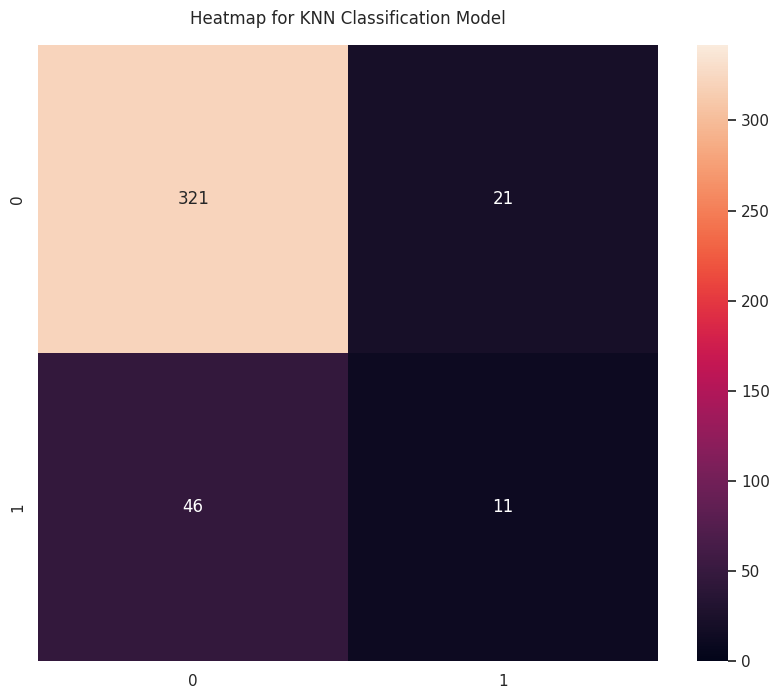

In [52]:
knn_cm = confusion_matrix(y_true=y_test,
                         y_pred=y_pred_knn)

plt.figure(figsize = (10,8))
ax = plt.axes()
x_axis_labels = ['0','1'] # labels for x-axis
y_axis_labels = ['0','1'] # labels for y-axis
vmax = max(np.unique(y_test, return_counts=True)[1])
sns.heatmap(knn_cm,
            vmin=0,
            vmax=vmax,
            annot=True,
            fmt="d",
            ax = ax,
            xticklabels=x_axis_labels,
            yticklabels=y_axis_labels)
ax.set_title('Heatmap for KNN Classification Model',pad=15)

In [53]:
print(classification_report(y_test, y_pred_knn, target_names=['0','1']))
print("Accuracy:",accuracy_score(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.87      0.94      0.91       342
           1       0.34      0.19      0.25        57

    accuracy                           0.83       399
   macro avg       0.61      0.57      0.58       399
weighted avg       0.80      0.83      0.81       399

Accuracy: 0.8320802005012531


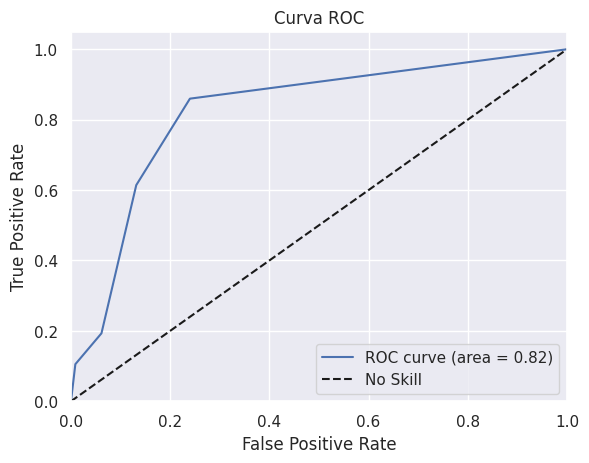

In [54]:
y_pred_proba_knn = knn.predict_proba(X_test)[:,1]

# Calculate ROC curve
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_proba_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)
# Plot the ROC curve
plt.figure()
plt.plot(fpr_knn, tpr_knn, label='ROC curve (area = %0.2f)' % roc_auc_knn)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()


Refinando parâmetros - kNN

Aqui vamos alterar somente o valor de k, mas podemos alterar outros valores, como por exemplo a distância utilizada

In [55]:
k_list = list(range(1,31)) # cria lista de valores para k
knn_param = dict(n_neighbors=k_list) # transforma em dicionario

### **Explicação**
- Cria uma lista de valores para **k** de **1 a 30**.
- Converte a lista em um **dicionário**, que será usado na busca pelo melhor `k`.

Grid Search

Referência: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

In [56]:
grid = GridSearchCV(knn,
                    knn_param,
                    cv=10,
                    # scoring='precision_macro') # devido ao dataset desbalanceado, melhor para refinar o método
                    # scoring='accuracy')
                    # scoring='recall_macro')
                    scoring='f1')

grid.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(n_jobs=-1),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
                                         23, 24, 25, 26, 27, 28, 29, 30]},
             scoring='f1')

### **Explicação**
Usamos **`GridSearchCV`** para encontrar o melhor valor de **k** através da validação cruzada.

- **`cv=10`**: Usa **validação cruzada com 10 folds**, garantindo que todos os dados sejam usados para treino e teste.
- **`scoring='f1'`**: Otimiza o modelo com base na métrica **F1-score**, útil para **dados desbalanceados**.
- **`grid.fit(X_train, y_train)`**: Treina vários modelos KNN com diferentes valores de `k` e escolhe o melhor.

### **SUGESTÃO**
🔹 **Testar diferentes métricas** dependendo do objetivo:
- **Acurácia (`accuracy`)** se o conjunto de dados estiver balanceado.
- **Precisão (`precision_macro`)** se a classe positiva for mais importante.
- **Recall (`recall_macro`)** se for importante minimizar **falsos negativos**.

In [57]:
for i in ['mean_test_score']:
        print(i," : ",grid.cv_results_[i])
        scores = grid.cv_results_['mean_test_score']

best_k_values = sorted(zip(k_list, scores), key=lambda x: x[1], reverse=True)
print("Top 5 valores de k:", best_k_values[:5])

mean_test_score  :  [0.4144035  0.16926628 0.3500224  0.15466278 0.28864061 0.18752308
 0.26745318 0.15131047 0.23892287 0.0992579  0.11502382 0.0750333
 0.1288641  0.06080864 0.12165018 0.07517399 0.10884186 0.07638462
 0.10531642 0.03797802 0.06081836 0.03022222 0.02991453 0.02222222
 0.03845756 0.03055556 0.03022222 0.01666667 0.01666667 0.        ]
Top 5 valores de k: [(1, np.float64(0.4144035043141952)), (3, np.float64(0.3500224012419134)), (5, np.float64(0.28864061398117125)), (7, np.float64(0.2674531752307446)), (9, np.float64(0.23892286653914563))]


### **Explicação**
- Exibe a **média dos scores** obtidos em cada valor de `k`.
- Os resultados são extraídos de `grid.cv_results_`.

Melhores parametros {'n_neighbors': 1} com o valor da métrica 0.4144035043141952 


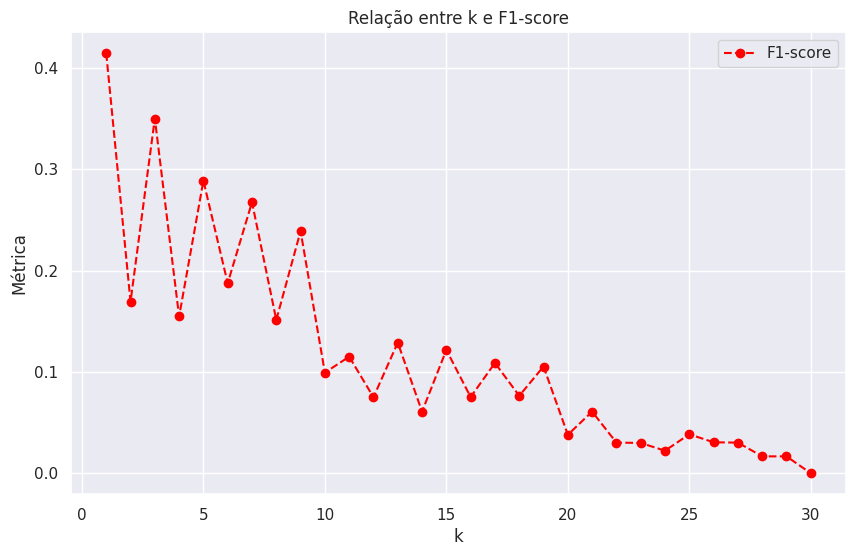

In [58]:
print("Melhores parametros {} com o valor da métrica {} ".format(grid.best_params_,grid.best_score_))
plt.figure(figsize=(10,6))
plt.plot(k_list,scores,color='red',linestyle='dashed',marker='o')
plt.xlabel('k')
plt.ylabel('Métrica')
plt.title('Relação entre k e F1-score')
plt.legend(['F1-score'])
plt.show()

### **Explicação**
- Exibe os **melhores parâmetros** e o **melhor score** encontrado no Grid Search.
- Plota um gráfico mostrando a relação entre **k** e a métrica escolhida.

kNN com melhor parâmetro

In [59]:
best_k = grid.best_params_['n_neighbors'] # usando o melhor valor para 'k'
knn = KNeighborsClassifier(n_neighbors=best_k,
                           weights='uniform',
                           algorithm='auto',
                           leaf_size=30,
                           p=2,
                           metric='minkowski',
                           metric_params=None,
                           n_jobs=-1)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_jobs=-1, n_neighbors=1)

In [60]:
y_pred_knn = knn.predict(X_test)

Text(0.5, 1.0, 'Heatmap for Decision Tree Classification Model')

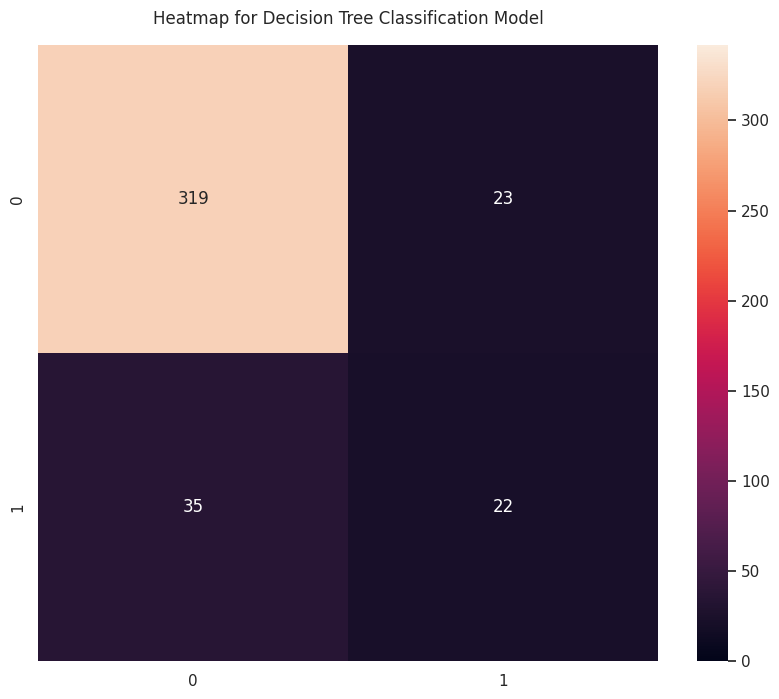

In [61]:
knn_cm = confusion_matrix(y_true=y_test,
                         y_pred=y_pred_knn)

plt.figure(figsize = (10,8))
ax = plt.axes()
x_axis_labels = ['0','1'] # labels for x-axis
y_axis_labels = ['0','1'] # labels for y-axis
vmax = max(np.unique(y_test, return_counts=True)[1])
sns.heatmap(knn_cm,
            vmin=0,
            vmax=vmax,
            annot=True,
            fmt="d",
            ax = ax,
            xticklabels=x_axis_labels,
            yticklabels=y_axis_labels)
ax.set_title('Heatmap for Decision Tree Classification Model',pad=15)


In [62]:
print(classification_report(y_test, y_pred_knn, target_names=['0','1']))
print("Accuracy:",accuracy_score(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.90      0.93      0.92       342
           1       0.49      0.39      0.43        57

    accuracy                           0.85       399
   macro avg       0.70      0.66      0.67       399
weighted avg       0.84      0.85      0.85       399

Accuracy: 0.8546365914786967


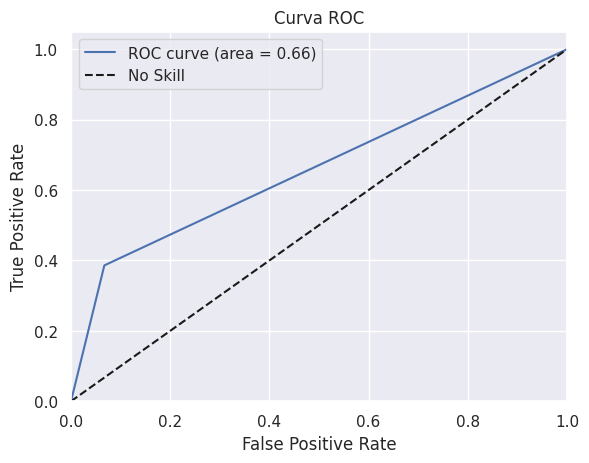

In [63]:
y_pred_proba_knn = knn.predict_proba(X_test)[:,1]

# Calculate ROC curve
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_proba_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)
# Plot the ROC curve
plt.figure()
plt.plot(fpr_knn, tpr_knn, label='ROC curve (area = %0.2f)' % roc_auc_knn)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()

## SVM

Referência: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC

In [64]:
from sklearn import svm

In [65]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

results = {}

for kernel in kernels:
  print("Learning kernel: ", kernel)
  svm_clf = svm.SVC(kernel=kernel, probability=True)

  svm_fit = svm_clf.fit(X_train, y_train)

  train_acc = svm_fit.score(X_train, y_train)
  test_acc = svm_fit.score(X_test, y_test)

  results[kernel] = (train_acc, test_acc)

  print("Accuracy score (training): {0:.3f}".format(svm_fit.score(X_train, y_train)))
  print("Accuracy score (teste): {0:.3f}".format(svm_fit.score(X_test, y_test)))
  print('\n')

# Exibir os resultados de forma organizada
print("----------------------------")
print("Kernel | Treino | Teste")
for k, (train_acc, test_acc) in results.items():
    print(f"{k:<7} | {train_acc:.3f} | {test_acc:.3f}")

Learning kernel:  linear
Accuracy score (training): 0.945
Accuracy score (teste): 0.952


Learning kernel:  poly
Accuracy score (training): 0.858
Accuracy score (teste): 0.857


Learning kernel:  rbf
Accuracy score (training): 0.858
Accuracy score (teste): 0.857


Learning kernel:  sigmoid
Accuracy score (training): 0.789
Accuracy score (teste): 0.784


----------------------------
Kernel | Treino | Teste
linear  | 0.945 | 0.952
poly    | 0.858 | 0.857
rbf     | 0.858 | 0.857
sigmoid | 0.789 | 0.784


### **Explicação**
Este bloco itera sobre **quatro kernels diferentes** do **Support Vector Machine (SVM)** e treina um modelo para cada um, comparando a acurácia no **treino** e **teste**.

Os **kernels testados** são:
- **`linear`**: Usa uma **reta de separação**. Funciona bem para dados linearmente separáveis.
- **`poly`**: Usa um **polinômio** como fronteira de decisão. Pode capturar relações mais complexas.
- **`rbf`** (Radial Basis Function): Cria **áreas de influência circulares** em torno dos dados.
- **`sigmoid`**: Se comporta como uma **função sigmoide**, similar a uma rede neural.

O código:
1. **Itera sobre cada kernel** e imprime qual está sendo testado.
2. **Treina um modelo SVM** com aquele kernel.
3. **Avalia a acurácia** no conjunto de treino e teste.

In [66]:
svm = svm.SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)

SVC(kernel='linear', probability=True)

### **Explicação**
- Depois de testar os kernels, o código **treina um modelo definitivo usando `kernel='linear'`**.
- O parâmetro `probability=True` ativa a **estimativa de probabilidades**, necessária para a **Curva ROC**.

In [67]:
y_pred_svm = svm.predict(X_test)

### **Explicação**
- **Prediz a classe (`0` ou `1`)** para os dados de teste usando o modelo treinado.

Text(0.5, 1.0, 'Heatmap for SVM - Linear Classification Model')

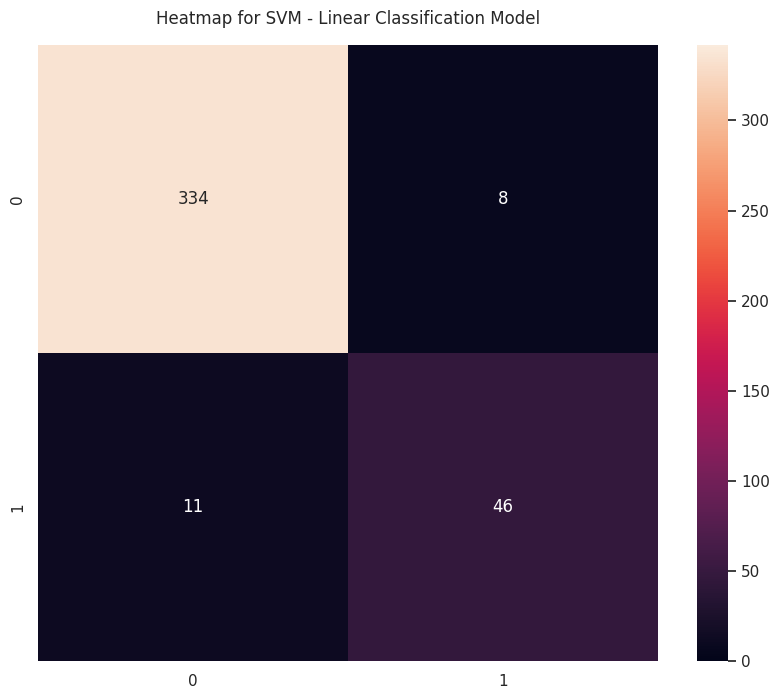

In [68]:
svm_cm = confusion_matrix(y_true=y_test,
                         y_pred=y_pred_svm)

plt.figure(figsize = (10,8))
ax = plt.axes()
x_axis_labels = ['0','1'] # labels for x-axis
y_axis_labels = ['0','1'] # labels for y-axis
vmax = max(np.unique(y_test, return_counts=True)[1])
sns.heatmap(svm_cm,
            vmin=0,
            vmax=vmax,
            annot=True,
            fmt="d",
            ax = ax,
            xticklabels=x_axis_labels,
            yticklabels=y_axis_labels)
ax.set_title('Heatmap for SVM - Linear Classification Model',pad=15)


In [69]:
print(classification_report(y_test, y_pred_svm, target_names=['0','1']))
print("Accuracy:",accuracy_score(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       342
           1       0.85      0.81      0.83        57

    accuracy                           0.95       399
   macro avg       0.91      0.89      0.90       399
weighted avg       0.95      0.95      0.95       399

Accuracy: 0.9523809523809523


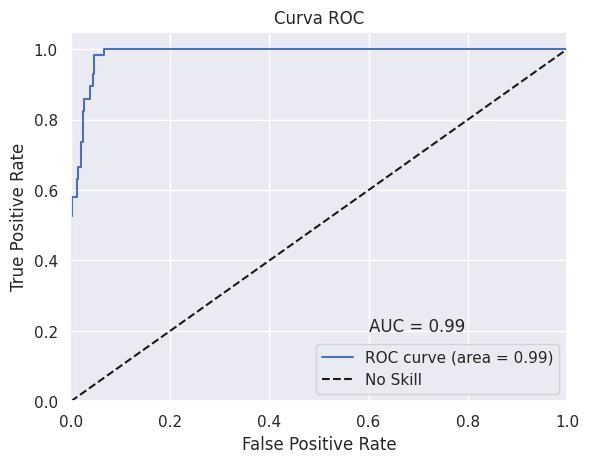

In [71]:
y_pred_proba_svm = svm.predict_proba(X_test)[:,1]

# Calculate ROC curve
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_proba_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)
# Plot the ROC curve
plt.figure()
plt.plot(fpr_svm, tpr_svm, label='ROC curve (area = %0.2f)' % roc_auc_svm)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.text(0.6, 0.2, f'AUC = {roc_auc_svm:.2f}', fontsize=12)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()

# Comparando os algoritmos

Curva ROC

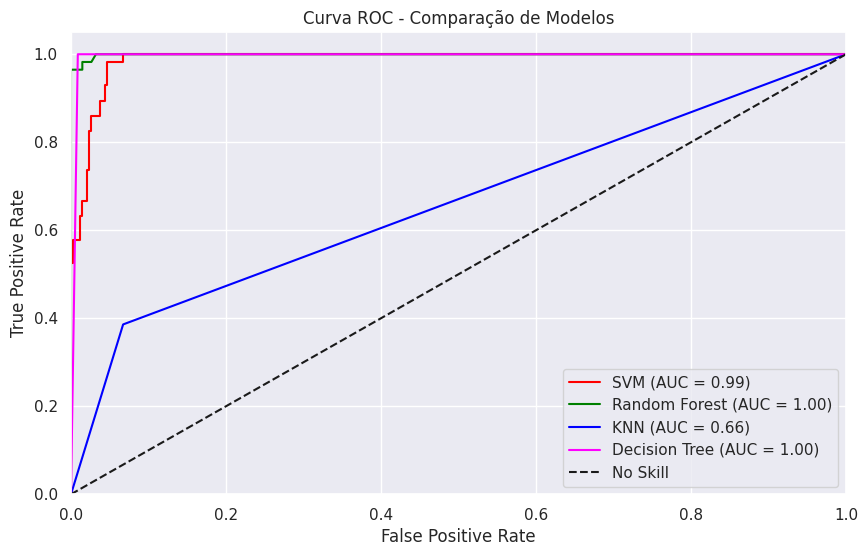

In [72]:
colors = ['red', 'green', 'blue', 'magenta']
models = ['SVM', 'Random Forest', 'KNN', 'Decision Tree']
roc_curves = [(fpr_svm, tpr_svm, roc_auc_svm),
              (fpr_rf, tpr_rf, roc_auc_rf),
              (fpr_knn, tpr_knn, roc_auc_knn),
              (fpr_dt, tpr_dt, roc_auc_dt)]

plt.figure(figsize=(10,6))

for i, (fpr, tpr, auc_score) in enumerate(roc_curves):
    plt.plot(fpr, tpr, color=colors[i], label=f'{models[i]} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Comparação de Modelos')
plt.legend(loc="lower right")
plt.show()

### **Explicação**
- O código **compara o desempenho dos classificadores** SVM, Random Forest, kNN e Decision Tree pela **Curva ROC**.
- A curva ROC mostra a **taxa de verdadeiros positivos (TPR) vs. taxa de falsos positivos (FPR)**.
- **AUC (Área sob a curva)** indica o quão bem o modelo distingue entre classes:
  - **AUC próximo de 1** → Modelo excelente.
  - **AUC próximo de 0.5** → Modelo aleatório.

Métricas

In [73]:
from sklearn.metrics import precision_score, recall_score

# Decision Tree
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
# print("Decision Tree:")
# print(f"Precision: {precision_dt}")
# print(f"Recall: {recall_dt}")
# print(f"Accuracy: {accuracy_score(y_test, y_pred_dt)}")


# Random Forest
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
# print("\nRandom Forest:")
# print(f"Precision: {precision_rf}")
# print(f"Recall: {recall_rf}")
# print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)}")


# kNN
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
# print("\nkNN:")
# print(f"Precision: {precision_knn}")
# print(f"Recall: {recall_knn}")
# print(f"Accuracy: {accuracy_score(y_test, y_pred_knn)}")


# SVM
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
# print("\nSVM:")
# print(f"Precision: {precision_svm}")
# print(f"Recall: {recall_svm}")
# print(f"Accuracy: {accuracy_score(y_test, y_pred_svm)}")

metrics = {
    "Modelo": ["Decision Tree", "Random Forest", "KNN", "SVM"],
    "Precisão": [precision_dt, precision_rf, precision_knn, precision_svm],
    "Recall": [recall_dt, recall_rf, recall_knn, recall_svm],
    "Acurácia": [accuracy_score(y_test, y_pred_dt),
                 accuracy_score(y_test, y_pred_rf),
                 accuracy_score(y_test, y_pred_knn),
                 accuracy_score(y_test, y_pred_svm)]
}

df_metrics = pd.DataFrame(metrics)
print(df_metrics)

          Modelo             Precisão               Recall             Acurácia
0  Decision Tree                 0.95                 1.00                 0.99
1  Random Forest                 1.00                 0.96                 0.99
2            KNN                 0.49                 0.39                 0.85
3            SVM                 0.85                 0.81                 0.95


### **Explicação**
- Calcula **precisão (`precision_score`)**, **recall (`recall_score`)** e **acurácia (`accuracy_score`)** para cada modelo.
- **Precisão**: % de previsões positivas corretas.
- **Recall**: % de positivos corretamente identificados.
- **Acurácia**: % de acertos totais.

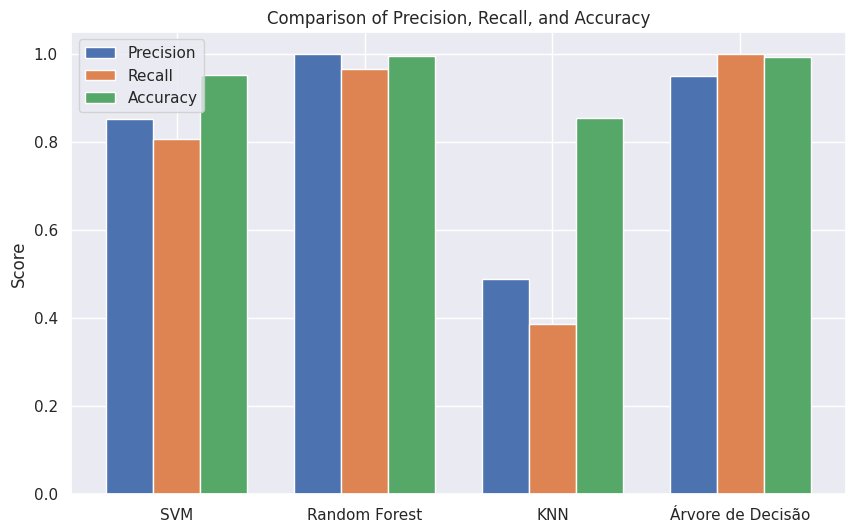

In [74]:
recall = [recall_svm, recall_rf, recall_knn, recall_dt]
accuracy = [accuracy_score(y_test, y_pred_svm), accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_knn), accuracy_score(y_test, y_pred_dt)]
precision = [precision_svm, precision_rf, precision_knn, precision_dt]

# alterar para cada metrica e analisar

name_classifier=['SVM', 'Random Forest', 'KNN', 'Árvore de Decisão']
metrics = [precision, recall, accuracy]
metric_names = ['Precision', 'Recall', 'Accuracy']
x = np.arange(len(name_classifier))

fig, ax = plt.subplots(figsize=(10,6))
bar_width = 0.25

for i in range(len(metrics)):
    ax.bar(x + i * bar_width, metrics[i], bar_width, label=metric_names[i])

ax.set_xticks(x + bar_width)
ax.set_xticklabels(name_classifier)
ax.set_ylabel('Score')
ax.set_title('Comparison of Precision, Recall, and Accuracy')
ax.legend()
plt.show()

### **Explicação**
- **Gera um gráfico de barras para visualizar as métricas** de cada modelo.
- Cada barra representa a **precisão** do modelo correspondente.
- Usa `plt.text()` para exibir o nome do modelo acima de cada barra.